In [1]:
import torch
from torch import nn
import torchvision
from torchvision import transforms

torch.cuda.is_available()

True

In [2]:
# load mnist dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = torchvision.datasets.MNIST( root='./data', 
                                            train=True, 
                                            transform=transform,
                                            download=True)
test_dataset = torchvision.datasets.MNIST( root='./data', 
                                           train=False, 
                                           transform=transform,
                                           download=True)

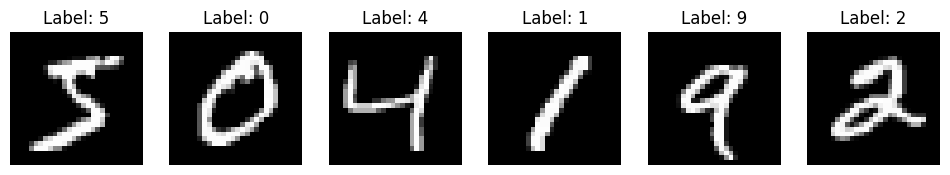

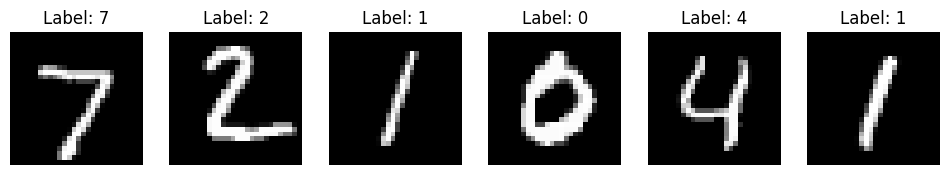

In [3]:
# show some sample images
import matplotlib.pyplot as plt

def show_images(dataset, num_images=6):
    fig, axes = plt.subplots(1, num_images, figsize=(num_images * 2, 2))
    for i in range(num_images):
        image, label = dataset[i]
        axes[i].imshow(image.squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label}')
        axes[i].axis('off')
    plt.show()

show_images(train_dataset)
show_images(test_dataset)


In [12]:
class AutoEncoderModel(nn.Module):
    def __init__(self, input_dim=28*28, latent_dim=64):
        super(AutoEncoderModel, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 32 x 14 x 14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 64 x 7 x 7
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # 32 x 14 x 14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1), # 1 x 28 x 28
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


In [13]:
# create train and test dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [14]:
# train the autoencoder
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')
model = AutoEncoderModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 30

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            test_loss += loss.item() * images.size(0)
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')


Using device: cuda
Epoch [1/30], Train Loss: 0.0312, Test Loss: 0.0012
Epoch [2/30], Train Loss: 0.0007, Test Loss: 0.0008
Epoch [3/30], Train Loss: 0.0004, Test Loss: 0.0004
Epoch [4/30], Train Loss: 0.0003, Test Loss: 0.0003
Epoch [5/30], Train Loss: 0.0003, Test Loss: 0.0002
Epoch [6/30], Train Loss: 0.0002, Test Loss: 0.0002
Epoch [7/30], Train Loss: 0.0002, Test Loss: 0.0001
Epoch [8/30], Train Loss: 0.0002, Test Loss: 0.0001
Epoch [9/30], Train Loss: 0.0002, Test Loss: 0.0001
Epoch [10/30], Train Loss: 0.0002, Test Loss: 0.0001
Epoch [11/30], Train Loss: 0.0002, Test Loss: 0.0001
Epoch [12/30], Train Loss: 0.0001, Test Loss: 0.0001
Epoch [13/30], Train Loss: 0.0001, Test Loss: 0.0001
Epoch [14/30], Train Loss: 0.0001, Test Loss: 0.0000
Epoch [15/30], Train Loss: 0.0001, Test Loss: 0.0001
Epoch [16/30], Train Loss: 0.0001, Test Loss: 0.0001
Epoch [17/30], Train Loss: 0.0001, Test Loss: 0.0001
Epoch [18/30], Train Loss: 0.0001, Test Loss: 0.0003
Epoch [19/30], Train Loss: 0.0001, T

In [8]:
# show model diagram
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 14, 14]             320
              ReLU-2           [-1, 32, 14, 14]               0
            Conv2d-3             [-1, 64, 7, 7]          18,496
              ReLU-4             [-1, 64, 7, 7]               0
   ConvTranspose2d-5           [-1, 32, 14, 14]          18,464
              ReLU-6           [-1, 32, 14, 14]               0
   ConvTranspose2d-7            [-1, 1, 28, 28]             289
           Sigmoid-8            [-1, 1, 28, 28]               0
Total params: 37,569
Trainable params: 37,569
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.25
Params size (MB): 0.14
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


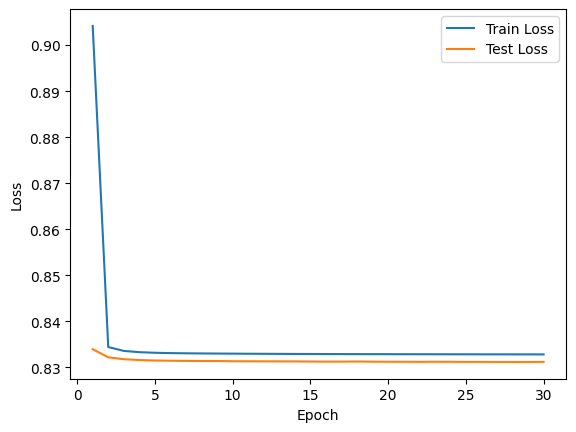

In [9]:
# plot loss curves
import matplotlib.pyplot as plt
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

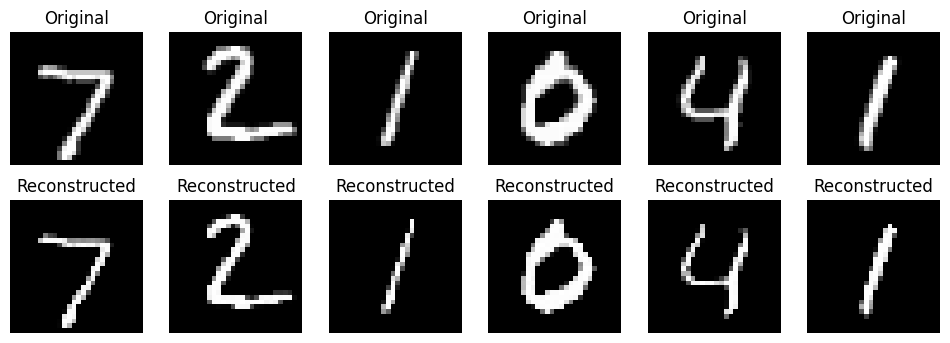

In [10]:
# visualize some reconstructed images
model.eval()
with torch.no_grad():
    sample_images, _ = next(iter(test_loader))
    sample_images = sample_images.to(device)
    reconstructed_images = model(sample_images)
    sample_images = sample_images.cpu()
    reconstructed_images = reconstructed_images.cpu()

    num_images = 6
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))
    for i in range(num_images):
        axes[0, i].imshow(sample_images[i].squeeze(), cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        axes[1, i].imshow(reconstructed_images[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')
    plt.show()

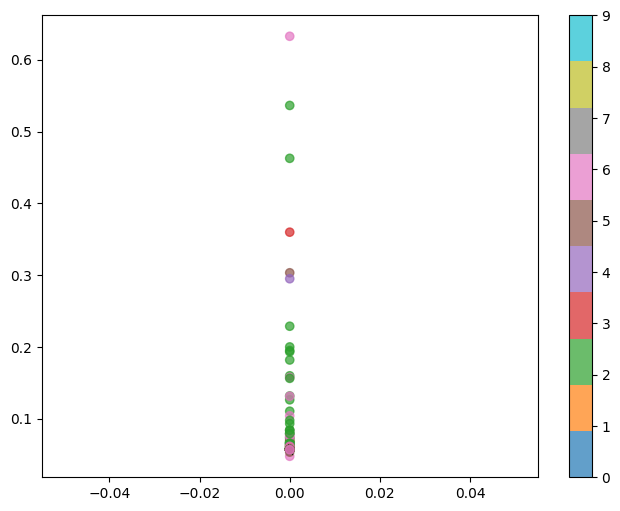

In [15]:
# plot latent space representations
import numpy as np
all_latents = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        latents = model.encoder(images)
        all_latents.append(latents.cpu().numpy().reshape(-1, 64*7*7))
        all_labels.append(labels.numpy())

all_latents = np.concatenate(all_latents, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(all_latents[:, 0], all_latents[:, 1], c=all_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))

Text(0.5, 1.0, 'Reconstructed')

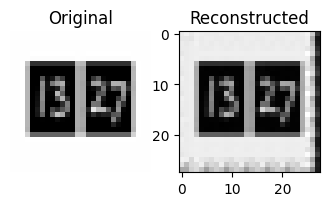

In [16]:
from PIL import Image
image = Image.open('test_1.png').convert('L')
image = image.resize((28, 28))
image = transform(image).unsqueeze(0).to(device)
model.eval()

# let's get the reconstructed image
with torch.no_grad():
    reconstructed_image = model(image)
    reconstructed_image = reconstructed_image.cpu().squeeze().numpy()

# plot original and reconstructed images
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(image.cpu().squeeze(), cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed')


Text(0.5, 1.0, 'Reconstructed')

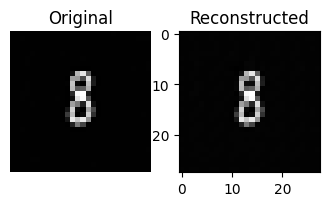

In [ ]:
from PIL import Image
image = Image.open('test_4.png').convert('L')
image = image.resize((28, 28))
image = transform(image).unsqueeze(0).to(device)
model.eval()

# let's get the reconstructed image
with torch.no_grad():
    reconstructed_image = model(image)
    reconstructed_image = reconstructed_image.cpu().squeeze().numpy()

# plot original and reconstructed images
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(image.cpu().squeeze(), cmap='gray')
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed')

In [1]:
1+1

2